# The FCI / SEVIRI readers and `harmonise`

[`pyramids_eo.sensors.readers`](../reference/readers.md) turn raw instrument granules into
calibrated, geolocated pyramids `Dataset`s. This notebook teaches the orchestration each
reader performs:

- `read_fci` - **stitch** a channel across its chunk set, **calibrate** it via the
  registry, and **geolocate** the result;
- `read_seviri` - **calibrate + geolocate** a single channel, with an injectable
  `.nat` decoder;
- `harmonise` - resample multi-resolution bands onto one common grid.

The raw byte decoders for the real formats need the EUMETSAT specs plus an actual
granule, so they are *injectable* (and the SEVIRI default deliberately raises). To keep
this notebook offline and reproducible we feed the readers **synthetic radiance
`Dataset`s** that stand in for decoded granule chunks — the stitch / calibrate /
geolocate logic exercised here is the real code path.

## Setup

Imports, matplotlib, and the pyramids `Dataset` builder.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
from pyramids.dataset import Dataset, GeoReference

from pyramids_eo.sensors.readers import harmonise, read_fci, read_seviri

## Synthetic FCI chunks

An FCI repeat cycle arrives as ~40 NetCDF chunks that tile the disk north-to-south.
Each chunk here is a small `Dataset` of raw radiance, georeferenced by its top-left
corner in EPSG:4326. We build two vertically-adjacent chunks with a smooth
north-south radiance gradient so the stitch is easy to see.

In [2]:
def radiance_chunk(top_lat: float, rows: int = 30, cols: int = 60) -> Dataset:
    # A synthetic FCI radiance chunk georeferenced by its top-left latitude.
    lat = np.linspace(top_lat, top_lat - rows * 0.1, rows)[:, None]
    lon = np.linspace(-15, 15, cols)[None, :]
    radiance = 40.0 + 0.4 * (60 - lat) + 3.0 * np.cos(np.deg2rad(4 * lon))
    return Dataset.from_array(
        radiance * np.ones((1, cols)),
        geo_ref=GeoReference(
            top_left_corner=(-15.0, top_lat), cell_size=0.1, epsg=4326
        ),
    )


north = radiance_chunk(60.0)
south = radiance_chunk(57.0)
print("north chunk:", north.shape, "top lat", north.geotransform[3])
print("south chunk:", south.shape, "top lat", south.geotransform[3])

north chunk: (1, 30, 60) top lat 60.0
south chunk: (1, 30, 60) top lat 57.0


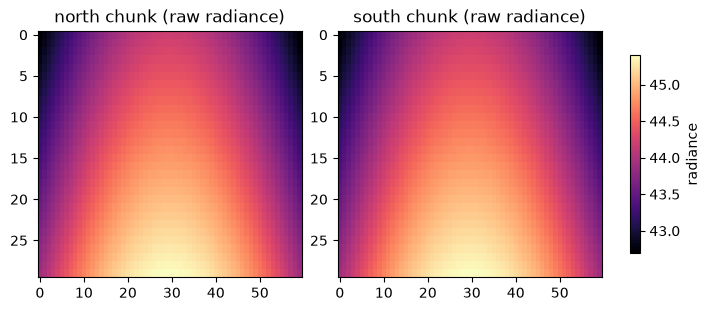

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True)
for ax, ds, title in ((axes[0], north, "north"), (axes[1], south, "south")):
    im = ax.imshow(ds.read_array(), cmap="magma", aspect="auto")
    ax.set_title(f"{title} chunk (raw radiance)")
_ = fig.colorbar(im, ax=axes, shrink=0.8, label="radiance")

## `read_fci` — stitch, calibrate, geolocate

`read_fci(chunks, channel)` orders the chunks north-to-south by their top-left latitude
(so you may pass them in any order), concatenates the radiance row-wise, calibrates it
for the requested channel, and returns a geolocated `Dataset`. For the thermal `ir_105`
channel the output is brightness temperature, and NaN is declared as the nodata value.

In [4]:
scene = read_fci([north, south], "ir_105")
print("stitched shape:", scene.shape)
print("CRS:", scene.epsg, "| top lat:", scene.geotransform[3])
print("nodata is NaN:", bool(np.isnan(scene.no_data_value[0])))

stitched shape: (1, 60, 60)
CRS: 4326 | top lat: 60.0
nodata is NaN: True


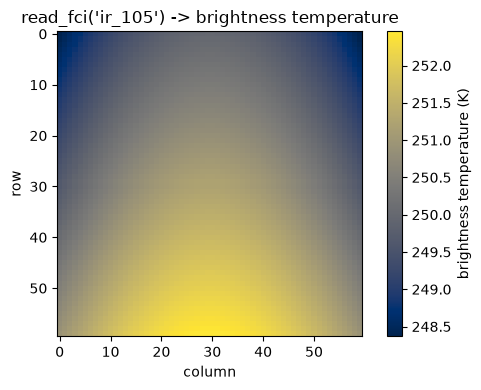

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 4))
im = ax.imshow(scene.read_array(), cmap="cividis")
ax.set_title("read_fci('ir_105') -> brightness temperature")
fig.colorbar(im, ax=ax, label="brightness temperature (K)")
ax.set_xlabel("column")
ax.set_ylabel("row")
fig.tight_layout()

The two chunks are now one continuous field and the values are physical temperatures,
not raw radiance. The result carries the **northernmost** chunk's geotransform, so it is
correctly placed regardless of the order the chunks were passed in - swapping the input
order gives an identical scene.

In [6]:
reversed_scene = read_fci([south, north], "ir_105")
print(
    "same result, order-independent:",
    bool(np.allclose(scene.read_array(), reversed_scene.read_array())),
)
print(
    "origin still the north chunk:", reversed_scene.geotransform == north.geotransform
)

same result, order-independent: True
origin still the north chunk: True


Pass `calibrate=False` to get the stitched **raw radiance** instead — useful when you
carry your own calibration downstream.

In [7]:
raw = read_fci([north, south], "ir_105", calibrate=False)
print(
    "raw radiance range:",
    round(float(raw.read_array().min()), 1),
    "->",
    round(float(raw.read_array().max()), 1),
)

raw radiance range: 41.5 -> 45.4


For real granules you would pass the file's own calibration via `coeffs` (preferred over
the nominal registry table), and an `open_chunk` callable that knows the real FCI L1C
group layout (`data/<channel>/measured/effective_radiance`). Here `coeffs` shifts the
brightness temperature to demonstrate the override taking effect.

In [8]:
granule = read_fci(
    [north, south],
    "ir_105",
    coeffs={"central_wavenumber_cm1": 900.0, "alpha": 0.99, "beta": 0.5},
)
delta = granule.read_array() - scene.read_array()
print("mean BT shift from granule coeffs (K):", round(float(delta.mean()), 2))

mean BT shift from granule coeffs (K): -4.27


## `read_seviri` — calibrate + geolocate with an injectable decoder

The MSG SEVIRI native `.nat` format is packed binary; decoding it needs the EUMETSAT
Level-1.5 spec and a real granule, so the bundled default `parse` raises
`NotImplementedError` on purpose. You supply either a `Dataset` already holding the
channel radiance, or a `parse(source, channel) -> Dataset` callable. The calibrate +
geolocate step around it is the real, tested code.

In [9]:
def parse_stub(source, channel):
    # Stand-in .nat decoder: return synthetic radiance as a Dataset.
    radiance = np.full((20, 30), 90.0)
    return Dataset.from_array(
        radiance,
        geo_ref=GeoReference(top_left_corner=(0.0, 40.0), cell_size=0.1, epsg=4326),
    )


seviri_scene = read_seviri("granule.nat", "IR_108", parse=parse_stub)
print(
    "SEVIRI IR_108 -> brightness temperature (K):",
    round(float(seviri_scene.read_array()[0, 0]), 2),
)
print("geolocated:", seviri_scene.epsg, seviri_scene.shape)

SEVIRI IR_108 -> brightness temperature (K): 286.03
geolocated: 4326 (1, 20, 30)


Note `IR_108` uses SEVIRI's *published Meteosat-9* inverse-Planck constants
(`alpha`/`beta`), not the identity correction FCI falls back to - the registry keeps the
per-sensor calibration honest.

## `harmonise` — one common grid

FCI and SEVIRI channels arrive at different native resolutions (FCI: 0.5 / 1 / 2 km), so
before you can stack them into a composite they must share a grid. `harmonise(bands,
reference)` resamples every band onto the reference `Dataset`'s grid (CRS + rows/columns
+ cell size) via pyramids' `align`. Here a coarse 0.2-deg band is brought onto a fine
0.1-deg reference.

In [10]:
reference = Dataset.from_array(
    np.zeros((40, 60)),
    geo_ref=GeoReference(top_left_corner=(-15.0, 60.0), cell_size=0.1, epsg=4326),
)
coarse = Dataset.from_array(
    np.arange(20 * 30, dtype=float).reshape(20, 30),
    geo_ref=GeoReference(top_left_corner=(-15.0, 60.0), cell_size=0.2, epsg=4326),
)
aligned = harmonise({"coarse": coarse}, reference)["coarse"]
print("coarse grid:", coarse.shape, "-> aligned grid:", aligned.shape)
print("matches reference grid:", aligned.shape == reference.shape)

coarse grid: (1, 20, 30) -> aligned grid: (1, 40, 60)
matches reference grid: True


Text(0.5, 1.0, 'harmonised (1, 40, 60)')

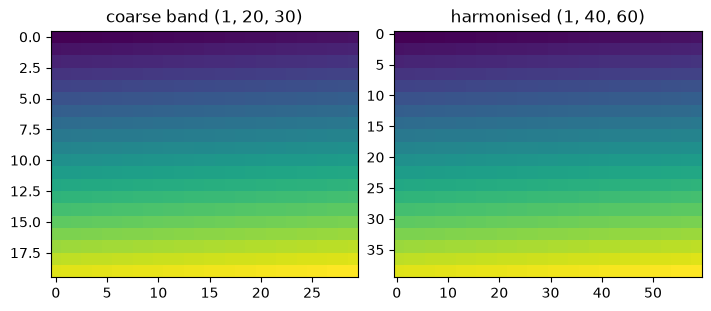

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True)
axes[0].imshow(coarse.read_array(), cmap="viridis", aspect="auto")
axes[0].set_title(f"coarse band {coarse.shape}")
axes[1].imshow(aligned.read_array(), cmap="viridis", aspect="auto")
axes[1].set_title(f"harmonised {aligned.shape}")

The coarse band now sits on the reference's finer grid, co-registered pixel-for-pixel
with anything else harmonised onto the same reference — ready to stack into a composite.
Pass `method="bilinear"` (or `"cubic"`) for continuous radiometric bands where
nearest-neighbour would look blocky.

## Takeaway

- `read_fci` stitches a channel across its chunk set, calibrates it, and geolocates it
  from the northernmost chunk - order-independent, with NaN nodata.
- `read_seviri` calibrates + geolocates one channel; its `.nat` byte decoder is
  injectable (the default deliberately raises) so you plug in a real parser or a
  `Dataset`.
- Both prefer per-granule `coeffs` over the registry, and `harmonise` puts
  multi-resolution bands onto one common grid.

Next: [Day/night compositing](day_night_compositing.ipynb) stacks harmonised, calibrated
bands into the `true_color_with_night_ir` image.